## Imports and Global Variables

In [166]:
import numpy as np
import cv2
import matplotlib.pyplot as plt

input_folder_path = "../media/input"
output_folder_path = "../media/output"

## Helper Functions (Nothing to do with the algorithms)

In [167]:
def plot_img_and_maps(img, maps, titles):
    fig, axs = plt.subplots(1, len(maps) + 1, figsize=(20, 10))
    axs[0].imshow(img)
    axs[0].set_title("Original Image")
    axs[0].axis('off')
    for i, (map, title) in enumerate(zip(maps, titles)):
        axs[i + 1].imshow(map)
        axs[i + 1].set_title(title)
        axs[i + 1].axis('off')
    plt.show()

## Reading Input Image and Feature Maps

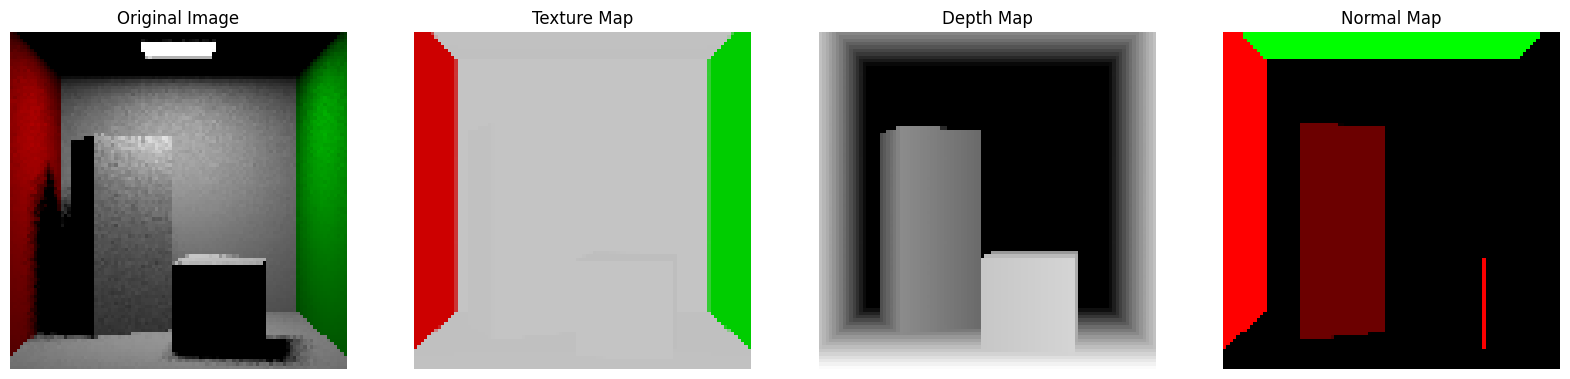

In [168]:
a = 100

# Note: We are resizing the images to 200x200 for faster processing (will remove later when everything is working)
noisy_image = cv2.resize(cv2.imread(input_folder_path + "/cuboids/100.png"), (a, a))       # Noisy Image
noisy_image = cv2.cvtColor(noisy_image, cv2.COLOR_BGR2RGB)  
texture_map = cv2.resize(cv2.imread(input_folder_path + "/cuboids/texture.png"), (a, a))   # Texture Map
texture_map = cv2.cvtColor(texture_map, cv2.COLOR_BGR2RGB)
depth_map = cv2.resize(cv2.imread(input_folder_path + "/cuboids/depth.png"), (a, a))       # Depth Map
depth_map = cv2.cvtColor(depth_map, cv2.COLOR_BGR2RGB)
normal_map = cv2.resize(cv2.imread(input_folder_path + "/cuboids/normal.png"), (a, a))     # Normal Map
normal_map = cv2.cvtColor(normal_map, cv2.COLOR_BGR2RGB)

# Plotting the image and feature maps
plot_img_and_maps(noisy_image, [texture_map, depth_map, normal_map], ["Texture Map", "Depth Map", "Normal Map"])

## Feature Maps Prefiltering

In [175]:
def sobel_gradient(image):
    """Calculate gradient magnitude using Sobel operator."""
    Gx = cv2.Sobel(image, cv2.CV_64F, 1, 0, ksize=3)  # Horizontal gradients
    Gy = cv2.Sobel(image, cv2.CV_64F, 0, 1, ksize=3)  # Vertical gradients
    gradient_magnitude = np.sqrt(Gx**2 + Gy**2)
    return gradient_magnitude

def guided_image_filter(I, P, radius=7, eps=0.001):
    """Apply guided image filtering."""
    mean_I = cv2.boxFilter(I, -1, (radius, radius))
    mean_P = cv2.boxFilter(P, -1, (radius, radius))
    mean_I_P = cv2.boxFilter(I * P, -1, (radius, radius))
    cov_I_P = mean_I_P - mean_I * mean_P
    
    mean_II = cv2.boxFilter(I * I, -1, (radius, radius))
    var_I = mean_II - mean_I * mean_I
    
    a = cov_I_P / (var_I + eps)
    b = mean_P - a * mean_I
    
    mean_a = cv2.boxFilter(a, -1, (radius, radius))
    mean_b = cv2.boxFilter(b, -1, (radius, radius))
    
    output = mean_a * I + mean_b
    return output

def prefilter_features(texture_map, depth_map, normal_map):
    """Prefilter noisy features using the guided image filter."""
    # Normalise the features before calculating the gradients
    texture_map = texture_map / 255.0
    depth_map = depth_map / 255.0
    normal_map = normal_map / 255.0

    # Calculate gradients for each feature map
    gradient_texture = sobel_gradient(texture_map)
    gradient_depth = sobel_gradient(depth_map)
    gradient_normal = sobel_gradient(normal_map)
    
    # Combine gradients to get a robust guidance image
    combined_gradient = np.maximum.reduce([gradient_texture, gradient_depth, gradient_normal])
    
    # Filter each feature map using the guided image filter
    filtered_texture = np.clip(guided_image_filter(combined_gradient, texture_map), 0, 1)
    filtered_depth = np.clip(guided_image_filter(combined_gradient, depth_map), 0, 1)
    filtered_normal = np.clip(guided_image_filter(combined_gradient, normal_map), 0, 1)

    # Converting filters back to 0-255 range
    filtered_texture = (filtered_texture * 255).astype(np.uint8)
    filtered_depth = (filtered_depth * 255).astype(np.uint8)
    filtered_normal = (filtered_normal * 255).astype(np.uint8)
    
    return filtered_texture, filtered_depth, filtered_normal

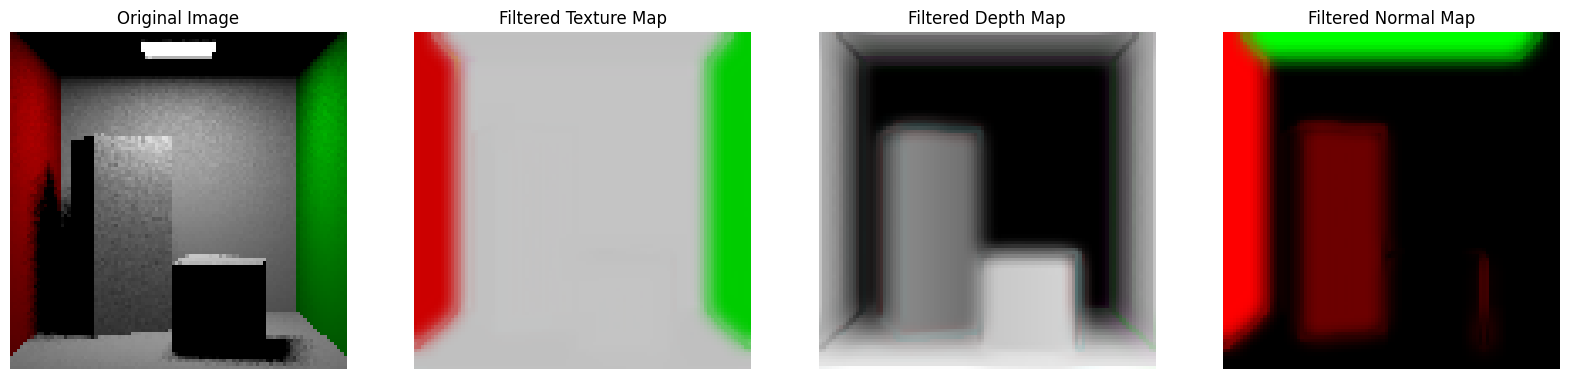

In [176]:
filtered_texture, filtered_depth, filtered_normal = prefilter_features(texture_map, depth_map, normal_map)

# Plotting the image and prefiltered feature maps
plot_img_and_maps(noisy_image, [filtered_texture, filtered_depth, filtered_normal], ["Filtered Texture Map", "Filtered Depth Map", "Filtered Normal Map"])

## Calculating Parameters

### Optimising $\alpha$ (Spatial Parameter) and $\beta$ (Color Parameter)

In [177]:
def compute_bias_variance(img, filtered_img):
    """
    Compute the bias and variance for a given alpha_t.
    Bias and variance are returned as scalars.
    """
    # Bias: Mean squared difference between filtered image and the original
    bias = np.mean((filtered_img - img) ** 2)

    # Variance: Variance across the filtered image
    variance = np.var(filtered_img)
    
    return bias, variance


def filter_image_alpha(img, alpha):
    """
    Apply spatial filtering to an image based on the given alpha.
    """
    kernel_size = int(alpha * 3)  # Adjust kernel size based on alpha
    kernel_size = kernel_size + 1 if kernel_size % 2 == 0 else kernel_size  # Ensure odd kernel size
    filtered_img = cv2.GaussianBlur(img, (kernel_size, kernel_size), alpha)
    return filtered_img

def filter_image_with_beta(img, beta):
    """
    Apply a filtering operation considering the color parameter beta.
    This is a placeholder for the actual filtering logic, 
    such as a bilateral filter or a color-sensitive smoothing filter.
    """
    # Example: Using bilateral filter to simulate color-based filtering
    filtered_img = cv2.bilateralFilter(img.astype(np.float32), d=5, sigmaColor=beta, sigmaSpace=5)
    return filtered_img

def optimize_spatial_and_color_parameters(img):
    """
    Optimize the spatial parameter (alpha) for each pixel.
    """
    height, width = img.shape[:2]
    optimal_alpha = np.zeros((height, width))
    optimal_beta = np.zeros((height, width))
    
    for i in range(height):
        for j in range(width):
            # Local window for filtering
            local_patch = img[max(0, i - 5):min(height, i + 6), max(0, j - 5):min(width, j + 6)]
            
            # Test a range of alpha values
            alphas = np.linspace(0.5, 8.0, 10)  # Range of alpha values
            best_alpha = alphas[0]
            min_error = float('inf')

            # Test a range of beta values
            betas = np.linspace(5, 100, 10)  # Range of beta values (color sensitivity)
            best_beta = betas[0]
            min_error = float('inf')
            
            for alpha, beta in zip(alphas, betas):
                filtered_patch_alpha = filter_image_alpha(local_patch, alpha)
                bias_alpha, variance_alpha = compute_bias_variance(local_patch, filtered_patch_alpha)

                filtered_patch_beta = filter_image_with_beta(local_patch, beta)
                bias_beta, variance_beta = compute_bias_variance(local_patch, filtered_patch_beta)
                
                # Sum of bias and variance as the error metric (scalar)
                error_alpha = bias_alpha + variance_alpha
                error_beta = bias_beta + variance_beta
                
                if error_alpha < min_error:
                    min_error = error_alpha
                    best_alpha = alpha

                if error_beta < min_error:
                    min_error = error_beta
                    best_beta = beta
            
            optimal_beta[i, j] = best_beta
            optimal_alpha[i, j] = best_alpha

    return optimal_alpha, optimal_beta

# optimal_alpha, optimal_beta = optimize_spatial_and_color_parameters(noisy_image)

## Optimising $\gamma$ (Feature Parameters)

In [201]:
def guided_filter(input_image, guidance_image, radius=5, eps=1e-6):
    """
    Perform guided filtering on the input image using the guidance image.
    """
    input_image = input_image.astype(np.float32)
    guidance_image = guidance_image.astype(np.float32)
    
    # Compute mean values
    mean_I = cv2.boxFilter(guidance_image, -1, (radius, radius))
    mean_P = cv2.boxFilter(input_image, -1, (radius, radius))
    mean_I_P = cv2.boxFilter(guidance_image * input_image, -1, (radius, radius))
    
    # Covariance of I and P
    cov_I_P = mean_I_P - mean_I * mean_P
    
    # Variance of I
    mean_II = cv2.boxFilter(guidance_image * guidance_image, -1, (radius, radius))
    var_I = mean_II - mean_I * mean_I
    
    # Linear coefficients a and b
    a = cov_I_P / (var_I + eps)
    b = mean_P - a * mean_I
    
    # Mean values of a and b
    mean_a = cv2.boxFilter(a, -1, (radius, radius))
    mean_b = cv2.boxFilter(b, -1, (radius, radius))
    
    # Compute the output image
    output = mean_a * guidance_image + mean_b
    return output

def compute_gamma(noisy_image, texture_map, normal_map, depth_map, eps=1e-6):
    """
    Compute the gamma values for texture, normal, and depth maps.
    
    Args:
        noisy_image (ndarray): Input noisy image.
        texture_map (ndarray): Texture map.
        normal_map (ndarray): Normal map.
        depth_map (ndarray): Depth map.
        eps (float): Small number to avoid division by zero.
    
    Returns:
        dict: A dictionary containing gamma arrays for texture, normal, and depth maps.
    """
    maps = {'texture': texture_map, 'normal': normal_map, 'depth': depth_map}
    gamma_values = {}
    
    # Perform guided filtering on the noisy image with each map
    filtered_images = {key: guided_filter(noisy_image, map_) for key, map_ in maps.items()}
    
    # Compute lambda and reference image
    lambda_values = {}
    for key, filtered_image in filtered_images.items():
        lambda_values[key] = np.abs(filtered_image - noisy_image) / (noisy_image + eps)
    
    # Reference image based on the minimum lambda
    min_lambda = np.minimum.reduce([lambda_values[key] for key in maps.keys()])
    ref_image = np.choose(np.argmin([lambda_values[key] for key in maps.keys()], axis=0), 
                          [filtered_images[key] for key in maps.keys()])
    
    # Compute error for each map
    for key, filtered_image in filtered_images.items():
        gamma_values[key] = ((filtered_image - ref_image) ** 2) / (ref_image ** 2 + eps)
    
    return gamma_values

# Compute gamma values
gamma_results = compute_gamma(noisy_image, filtered_texture, filtered_normal, filtered_depth)
print(gamma_results['texture'].shape)

(100, 100, 3)


In [193]:
# Parameters
alpha = 500000.0
beta = 10000000.0
gamma_t = 1.0
gamma_d = 1.0
gamma_n = 1.0

## Filtering Image

In [194]:
def cross_bilateral_filter(image, texture_map, depth_map, normal_map, alpha, beta, gamma_t, gamma_d, gamma_n):
    """
    Applies cross-bilateral filtering to the noisy input image.

    Args:
        image (numpy.ndarray): Noisy input image of shape (H, W, C).
        texture_map (numpy.ndarray): Texture map of shape (H, W).
        depth_map (numpy.ndarray): Depth map of shape (H, W).
        normal_map (numpy.ndarray): Normal map of shape (H, W, 3).
        alpha (float): Spatial weight parameter.
        beta (float): Color weight parameter.
        gamma_t (float): Texture map weight parameter.
        gamma_d (float): Depth map weight parameter.
        gamma_n (float): Normal map weight parameter.

    Returns:
        numpy.ndarray: Filtered image of the same shape as the input image.
    """
    H, W, C = image.shape
    filtered_image = np.zeros_like(image)
    spatial_coords = np.indices((H, W)).transpose(1, 2, 0)  # Pixel coordinates

    for i in range(H):
        for j in range(W):
            neighborhood = [(x, y) for x in range(max(0, i-1), min(H, i+2))
                            for y in range(max(0, j-1), min(W, j+2))]

            numerator = np.zeros(C)
            denominator = 0

            for x, y in neighborhood:
                # Spatial weight
                spatial_weight = np.exp(-np.linalg.norm(spatial_coords[i, j] - spatial_coords[x, y])**2 / (2 * alpha**2))

                # Color weight
                color_weight = np.exp(-np.linalg.norm(image[i, j] - image[x, y])**2 / (2 * beta**2))

                # Texture weight
                texture_weight = np.exp(-np.linalg.norm(texture_map[i, j] - texture_map[x, y])**2 / (2 * gamma_t**2))

                # Depth weight
                depth_weight = np.exp(-np.linalg.norm(depth_map[i, j] - depth_map[x, y])**2 / (2 * gamma_d**2))

                # Normal weight
                normal_weight = np.exp(-np.linalg.norm(normal_map[i, j] - normal_map[x, y])**2 / (2 * gamma_n**2))

                # Total weight
                weight = spatial_weight * color_weight * texture_weight * depth_weight * normal_weight

                numerator += weight * image[x, y]
                denominator += weight

            # Filtered pixel value
            filtered_image[i, j] = numerator / denominator if denominator != 0 else image[i, j]

    return filtered_image

# Example Usage
def apply_filter(image, texture_map, depth_map, normal_map, alpha, beta, gamma_t, gamma_d, gamma_n):
    """
    Wrapper to apply the cross-bilateral filter to the noisy image.

    Args:
        image (numpy.ndarray): Input noisy image.
        texture_map (numpy.ndarray): Texture map.
        depth_map (numpy.ndarray): Depth map.
        normal_map (numpy.ndarray): Normal map.
        alpha, beta, gamma_t, gamma_d, gamma_n: Filter parameters.

    Returns:
        numpy.ndarray: Filtered image.
    """

    # Apply the cross-bilateral filter
    return cross_bilateral_filter(image, texture_map, depth_map, normal_map, alpha, beta, gamma_t, gamma_d, gamma_n)

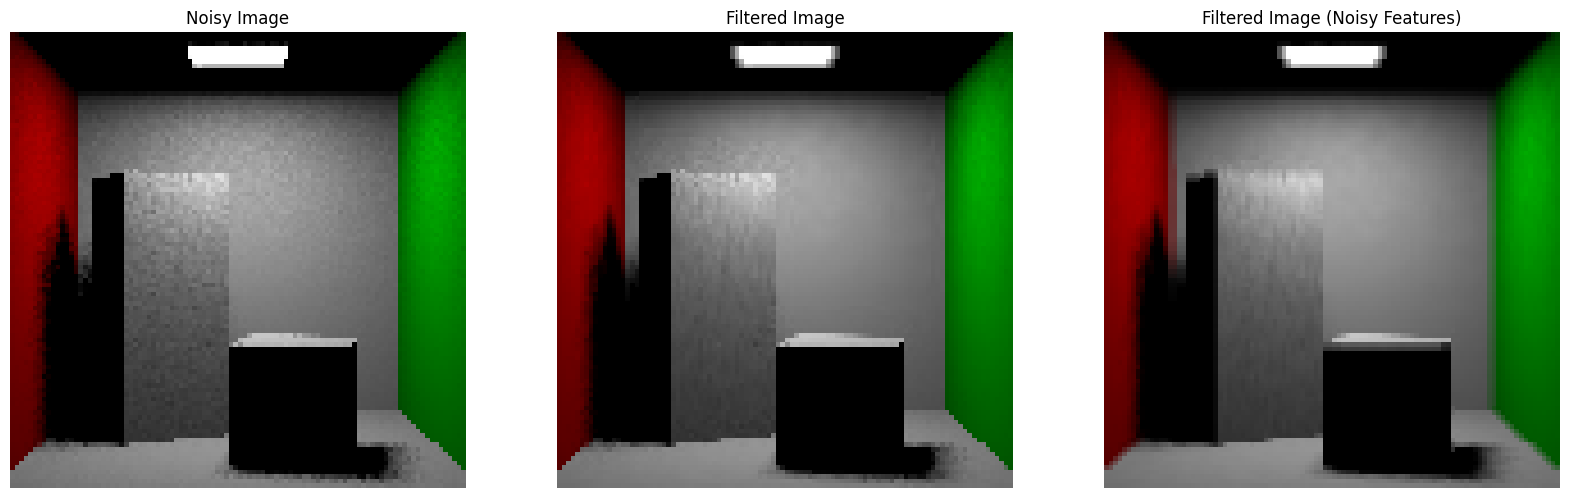

In [195]:
# Apply the filter
filtered_image = apply_filter(noisy_image, filtered_texture, filtered_depth, filtered_normal, alpha, beta, gamma_t, gamma_d, gamma_n)
filtered_image_noisy_features = apply_filter(noisy_image, texture_map, depth_map, normal_map, alpha, beta, gamma_t, gamma_d, gamma_n)

# Displaying the output for comparison
fig, ax = plt.subplots(1, 3, figsize=(20, 10))
ax[0].imshow(noisy_image)
ax[0].set_title("Noisy Image")
ax[0].axis("off")

ax[1].imshow(filtered_image)
ax[1].set_title("Filtered Image")
ax[1].axis("off")

ax[2].imshow(filtered_image_noisy_features)
ax[2].set_title("Filtered Image (Noisy Features)")
ax[2].axis("off")
plt.show()